In [1]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print
import shutil

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
own_region = "Big_shape_file" 
if own_region == None: 
    own_region = "Big_shape_file"

path = Path.cwd()
forcing_path = path / "Forcing"    
shapeFile = forcing_path / f"{own_region}.shp"

saveLocation = forcing_path / f"{own_region}Forcing"

In [3]:
experiment_start_time = "2001-01-01T00:00:00Z"
experiment_end_time = "2019-12-31T00:00:00Z"

In [4]:
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
    dataset="ERA5",
    start_time=experiment_start_time,
    end_time=experiment_end_time,
    shape=shapeFile.absolute(),
    
)


In [5]:
ds = ERA5_forcing.to_xarray()

df_forcing = pd.DataFrame({
    "date": pd.to_datetime(ds["time"].values),
    "P": ds["pr"].values,
    "Ep": ds["evspsblpot"].values
})

df_forcing["P"] *= 86400
df_forcing["Ep"] *= 86400

df_forcing.head()

,date,P,Ep
0,2001-01-01 12:00:00,0.000955,0.914243
1,2001-01-02 12:00:00,0.013607,1.158486
2,2001-01-03 12:00:00,0.086330,0.973780
3,2001-01-04 12:00:00,0.160776,1.077054
4,2001-01-05 12:00:00,0.926260,0.552120


In [6]:
df_q = pd.read_csv(
    "6228920_Q_Day.Cmd.txt",
    sep=";",
    comment="#",
    encoding="latin1",
    header=None,
    names=["date", "time", "Q"]
)

# remove the non-data row: YYYY-MM-DD;hh:mm; Value
df_q = df_q[df_q["date"] != "YYYY-MM-DD"].copy()

# clean columns
df_q["date"] = pd.to_datetime(df_q["date"], errors="coerce")
df_q["Q"] = pd.to_numeric(df_q["Q"], errors="coerce")

# remove missing GRDC values
df_q = df_q[(df_q["Q"] != -999.0) & (df_q["date"].notna())].copy()

# keep only what you need
df_q = df_q[["date", "Q"]]

df_q.head()

,date,Q
1,2001-06-01,1.552
29,2001-06-29,1.523
30,2001-06-30,1.552
31,2001-07-01,4.163
33,2001-07-03,1.089


In [7]:
df_forcing["date"] = pd.to_datetime(df_forcing["date"]).dt.normalize()
df_q["date"] = pd.to_datetime(df_q["date"]).dt.normalize()

In [34]:
area_km2 = 3156.2 
area_m2 = area_km2 * 1e6

print("Catchment area [km²]:", area_km2)

Catchment area : 3156.2

In [35]:
df_q["R"] = df_q["Q"] * 86400 / area_m2 * 1000
df_q.head()

,date,Q,R
1,2001-06-01,1.552,0.042486
29,2001-06-29,1.523,0.041692
30,2001-06-30,1.552,0.042486
31,2001-07-01,4.163,0.113961
33,2001-07-03,1.089,0.029811


In [36]:
df_forcing["date"] = pd.to_datetime(df_forcing["date"]).dt.normalize()
df_q["date"] = pd.to_datetime(df_q["date"]).dt.normalize()

df = pd.merge(df_forcing, df_q[["date", "R"]], on="date", how="inner")

df_month = df.set_index("date").resample("ME").sum()
df_month.head()

,P,Ep,R
date,,,
2001-06-30,11.921536,14.330514,0.126663
2001-07-31,83.691402,69.217473,0.797206
2001-08-31,0.000000,0.000000,0.000000
2001-09-30,0.000000,0.000000,0.000000
2001-10-31,19.785636,56.886590,1.140074


In [37]:
P_mean = df_month["P"].mean()
Ep_mean = df_month["Ep"].mean()
R_mean = df_month["R"].mean()

Ea_mean = P_mean - R_mean

print("P_mean =", P_mean)
print("Ep_mean =", Ep_mean)
print("R_mean =", R_mean)
print("Ea_mean =", Ea_mean)
print("Check closure =", P_mean - (Ea_mean + R_mean))

P_mean = 81.01047712924783

Ep_mean = 72.72009836385709

R_mean = 8.97592269070799

Ea_mean = 72.03455443853984

Check closure = 0.0

In [38]:
AI = Ep_mean / P_mean
EI_obs = Ea_mean / P_mean   # same as 1 - R_mean/P_mean

print("Aridity Index (Ep/P) =", AI)
print("Evaporative Index (Ea/P) =", EI_obs)
print("Check EI =", 1 - R_mean / P_mean)

Aridity Index (Ep/P) = 0.8976628818990426

Evaporative Index (Ea/P) = 0.8892004712379685

Check EI = 0.8892004712379685

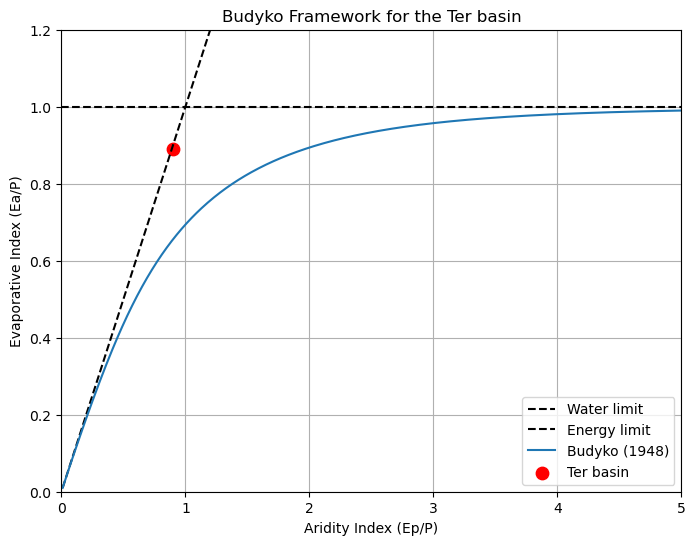

In [39]:
phi_range = np.linspace(0.01, 5, 500)

EaP_schreiber = 1 - np.exp(-phi_range)
EaP_oldekop = phi_range * np.tanh(1 / phi_range)
EaP_budyko = np.sqrt(phi_range * np.tanh(1/phi_range) * (1 - np.exp(-phi_range)))
EaP_turc = 1 / np.sqrt(0.9 + (1/phi_range)**2)

plt.figure(figsize=(8, 6))
plt.hlines(1, xmin=0, xmax=5, colors='black', linestyles='--', label='Water limit')
plt.plot(phi_range, phi_range, 'k--', label='Energy limit')
plt.plot(phi_range, EaP_budyko, label='Budyko (1948)')
plt.scatter(AI, EI_obs, color='red', s=80, label='Ter basin')

plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (Ea/P)")
plt.title("Budyko Framework for the Ter basin")
plt.xlim(0, 5)
plt.ylim(0, 1.2)
plt.grid(True)
plt.legend()
plt.show()

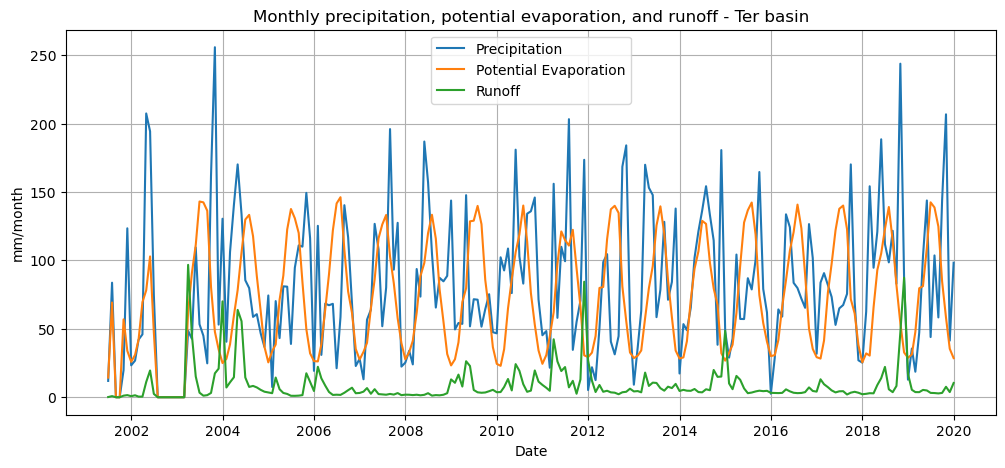

In [40]:
#shows seasonality
#Summer → high Ep, low P → water stress
#Winter → recharge period
plt.figure(figsize=(12,5))
plt.plot(df_month.index, df_month["P"], label="Precipitation")
plt.plot(df_month.index, df_month["Ep"], label="Potential Evaporation")
plt.plot(df_month.index, df_month["R"], label="Runoff")

plt.xlabel("Date")
plt.ylabel("mm/month")
plt.title("Monthly precipitation, potential evaporation, and runoff - Ter basin")
plt.legend()
plt.grid(True)
plt.show()

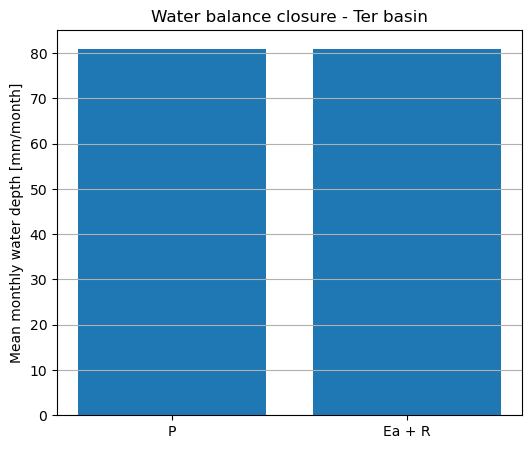

In [15]:
#plotwaterbalance
plt.figure(figsize=(6,5))
plt.bar(["P", "Ea + R"], [P_mean, Ea_mean + R_mean])

plt.ylabel("Mean monthly water depth [mm/month]")
plt.title("Water balance closure - Ter basin")
plt.grid(axis="y")
plt.show()

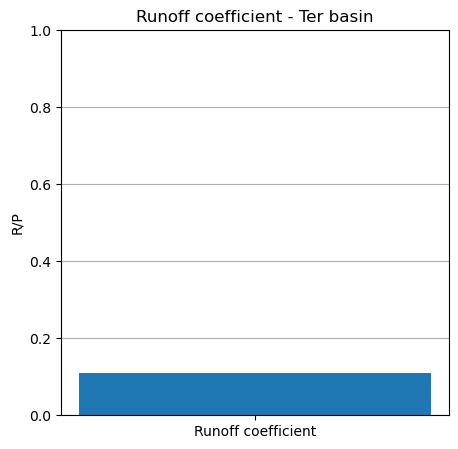

In [16]:
RC = R_mean / P_mean #Runoff coefficient
plt.figure(figsize=(5,5))
plt.bar(["Runoff coefficient"], [RC])
plt.ylim(0, 1)
plt.ylabel("R/P")
plt.title("Runoff coefficient - Ter basin")
plt.grid(axis="y")
plt.show()

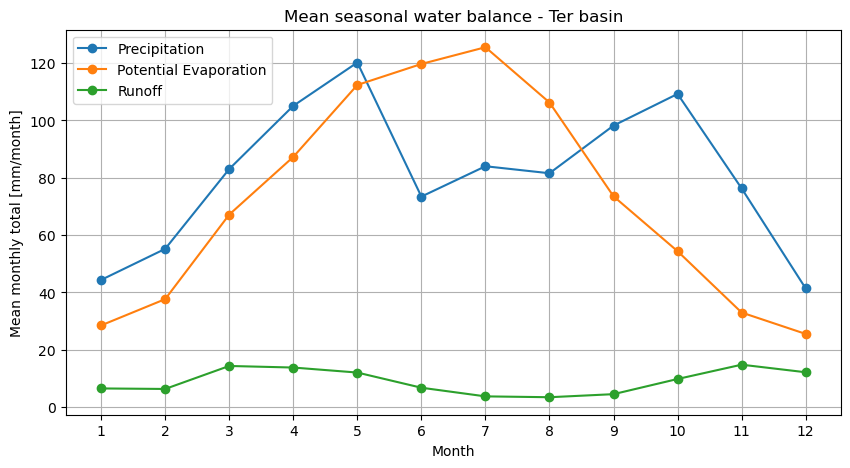

In [17]:
df_month_plot = df_month.copy()
df_month_plot["month"] = df_month_plot.index.month

monthly_climatology_sum = df_month_plot.groupby("month")[["P", "Ep", "R"]].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_climatology_sum.index, monthly_climatology_sum["P"], marker="o", label="Precipitation")
plt.plot(monthly_climatology_sum.index, monthly_climatology_sum["Ep"], marker="o", label="Potential Evaporation")
plt.plot(monthly_climatology_sum.index, monthly_climatology_sum["R"], marker="o", label="Runoff")

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Mean monthly total [mm/month]")
plt.title("Mean seasonal water balance - Ter basin")
plt.legend()
plt.grid(True)
plt.show()

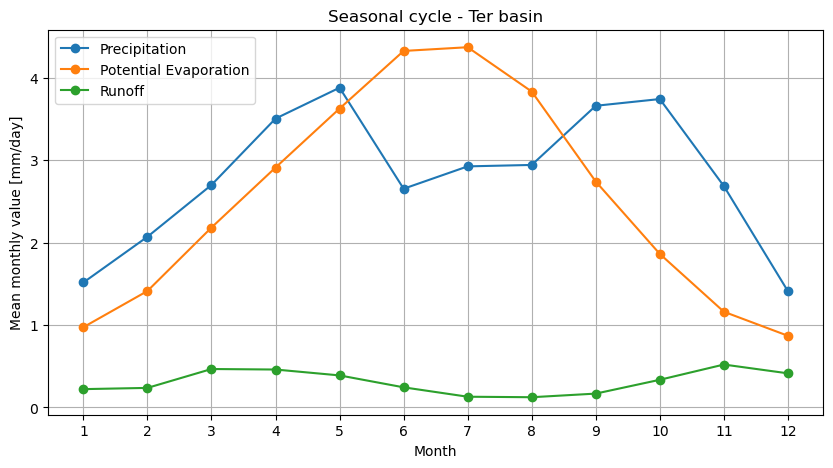

In [18]:
clim_month = df.copy()
clim_month["month"] = clim_month["date"].dt.month

monthly_climatology = clim_month.groupby("month")[["P", "Ep", "R"]].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_climatology.index, monthly_climatology["P"], marker="o", label="Precipitation")
plt.plot(monthly_climatology.index, monthly_climatology["Ep"], marker="o", label="Potential Evaporation")
plt.plot(monthly_climatology.index, monthly_climatology["R"], marker="o", label="Runoff")

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Mean monthly value [mm/day]")
plt.title("Seasonal cycle - Ter basin")
plt.legend()
plt.grid(True)
plt.show()

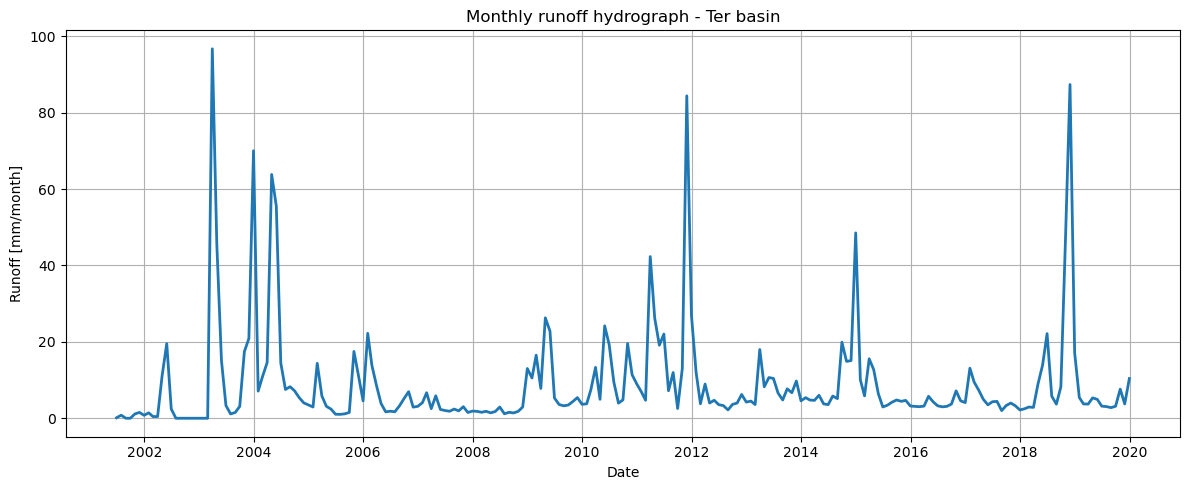

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df_month.index, df_month["R"], linewidth=2)

plt.xlabel("Date")
plt.ylabel("Runoff [mm/month]")
plt.title("Monthly runoff hydrograph - Ter basin")
plt.grid(True)
plt.tight_layout()
plt.show()

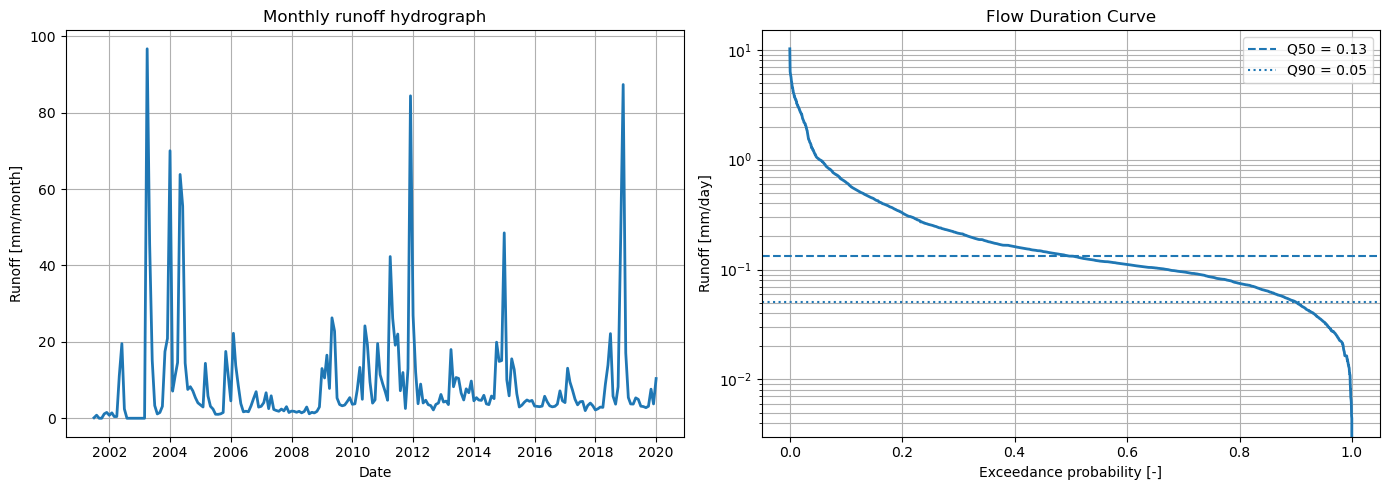

In [20]:
R = df["R"].dropna().values
R_sorted = np.sort(R)[::-1]
n = len(R_sorted)
exceedance = np.arange(1, n + 1) / (n + 1)

Q50 = np.percentile(R, 50)
Q90 = np.percentile(R, 10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# hydrograph
axes[0].plot(df_month.index, df_month["R"], linewidth=2)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Runoff [mm/month]")
axes[0].set_title("Monthly runoff hydrograph")
axes[0].grid(True)

# FDC
axes[1].semilogy(exceedance, R_sorted, linewidth=2)
axes[1].axhline(Q50, linestyle="--", linewidth=1.5, label=f"Q50 = {Q50:.2f}")
axes[1].axhline(Q90, linestyle=":", linewidth=1.5, label=f"Q90 = {Q90:.2f}")
axes[1].set_xlabel("Exceedance probability [-]")
axes[1].set_ylabel("Runoff [mm/day]")
axes[1].set_title("Flow Duration Curve")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

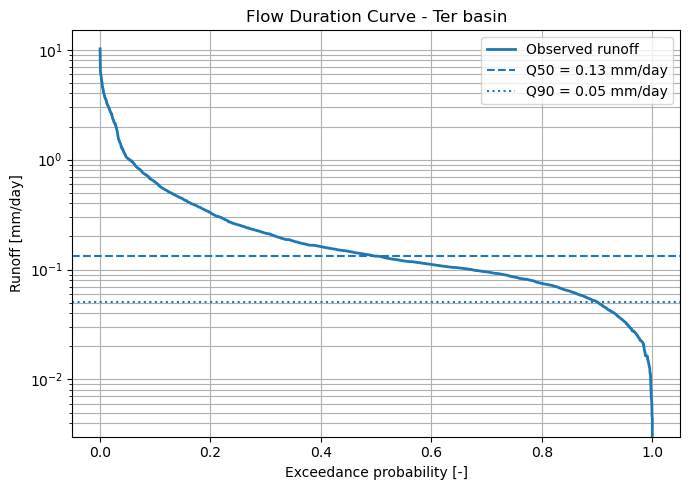

In [21]:
R = df["R"].dropna().values
R_sorted = np.sort(R)[::-1]
n = len(R_sorted)
exceedance = np.arange(1, n + 1) / (n + 1)

# characteristic flows from sorted series
Q50 = np.percentile(R, 50)
Q90 = np.percentile(R, 10)  # exceeded 90% of the time

plt.figure(figsize=(7,5))
plt.semilogy(exceedance, R_sorted, linewidth=2, label="Observed runoff")

plt.axhline(Q50, linestyle="--", linewidth=1.5, label=f"Q50 = {Q50:.2f} mm/day")
plt.axhline(Q90, linestyle=":", linewidth=1.5, label=f"Q90 = {Q90:.2f} mm/day")

plt.xlabel("Exceedance probability [-]")
plt.ylabel("Runoff [mm/day]")
plt.title("Flow Duration Curve - Ter basin")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()